In [1]:
import rebound
import reboundx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pd.set_option('display.precision', 20)

# Collisions with new mass less than min_frag_mass and collisions with the sun

## randseed = 2

In [2]:
def get_abs(a, b, c):
    return (a**2 + b**2 + c**2)**0.5

In [3]:
famtree_bigstep_2 = pd.read_csv(
    "famtree_bigstep_2",
    header=None, 
    names=[
        "t", "type", "new_id", "parent1_id", "parent2_id",
        "new_mass", "parent1_mass", "parent2_mass", "new_radius",
        "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
    ]
)

In [4]:
input_file = "heartbeat_bigstep_2"
output_file = "heartbeat_bigstep_2_reduced.txt"

# First, read all lines to find the total count
with open(input_file, "r") as infile:
    all_lines = infile.readlines()

total_lines = len(all_lines)
target_lines = total_lines // 5  
start_index = total_lines - target_lines

with open(output_file, "w") as outfile:
    line_count = 0
    
    for line in all_lines:
        # Keep lines only after reaching the start_index
        if line_count >= start_index:
            outfile.write(line)
            
        line_count = line_count + 1

In [12]:
heartbeat_column_names = [
    "t", "walltime", "N", "total_mass", 
    "ang_mom_x", "ang_mom_y", "ang_mom_z", "energy", 
    "p3_m", "p3_r", "p3_x", "p3_y", "p3_z", "p3_vx", "p3_vy", "p3_vz",
    "p0_m", "p0_r", "p0_x", "p0_y", "p0_z", "p0_vx", "p0_vy", "p0_vz"
]

# Read the files
heartbeat_bigstep_2 = pd.read_csv(
    "heartbeat_bigstep_2", 
    names=heartbeat_column_names, 
    header=None
)

: 

In [6]:
# 1. Get initial values (from the first row)
initial_mass = heartbeat_bigstep_2["total_mass"].iloc[0]
initial_energy = heartbeat_bigstep_2["energy"].iloc[0]

L_x0 = heartbeat_bigstep_2["ang_mom_x"].iloc[0]
L_y0 = heartbeat_bigstep_2["ang_mom_y"].iloc[0]
L_z0 = heartbeat_bigstep_2["ang_mom_z"].iloc[0]
initial_L_mag = np.sqrt(L_x0**2 + L_y0**2 + L_z0**2)

# 2. Calculate current angular momentum magnitude for all rows
current_L_mag = np.sqrt(
    heartbeat_bigstep_2["ang_mom_x"]**2 + 
    heartbeat_bigstep_2["ang_mom_y"]**2 + 
    heartbeat_bigstep_2["ang_mom_z"]**2
)

# 3. Add the relative error columns
heartbeat_bigstep_2["mass_error"] = abs((heartbeat_bigstep_2["total_mass"] - initial_mass) / initial_mass)
heartbeat_bigstep_2["energy_error"] = abs((heartbeat_bigstep_2["energy"] - initial_energy) / initial_energy)
heartbeat_bigstep_2["angular_momentum_error"] = abs((current_L_mag - initial_L_mag) / initial_L_mag)

In [7]:
famtree_less_than_min_mass = famtree_bigstep_2[famtree_bigstep_2['new_mass'] < 1.4e-8]
famtree_less_than_min_mass

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
18,40212.36000000000058207661,8,61,56,58,0.0000000001144025,0.00000010233470,0.00000006251261,0.000001755302,0.000016912750,0.000014350350,15.63508999999999993236,0.64867339999999995559
94,45191.84999999999854480848,8,146,68,75,0.0000000004371206,0.00000001496878,0.00000001493203,0.000002744145,0.000008911185,0.000008903887,3.13319299999999989481,0.64252379999999997828


In [8]:
coll_newid_61 = famtree_less_than_min_mass[famtree_less_than_min_mass['new_id'] == 61]
coll_newid_61

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
18,40212.36000000000058207661,8,61,56,58,0.0000000001144025,0.0000001023347,0.00000006251261,0.000001755302,0.00001691275,0.00001435035,15.63508999999999993236,0.64867339999999995559


In [9]:
coll_newid_146 = famtree_less_than_min_mass[famtree_less_than_min_mass['new_id'] == 146]
coll_newid_146

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
94,45191.84999999999854480848,8,146,68,75,0.0000000004371206,0.00000001496878,0.00000001493203,0.000002744145,0.000008911185,0.000008903887,3.13319299999999989481,0.64252379999999997828


In [10]:
famtree_with_sun = famtree_bigstep_2[(np.isclose(famtree_bigstep_2['parent1_mass'], 1)) | (np.isclose(famtree_bigstep_2['parent2_mass'], 1))]
famtree_with_sun

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp


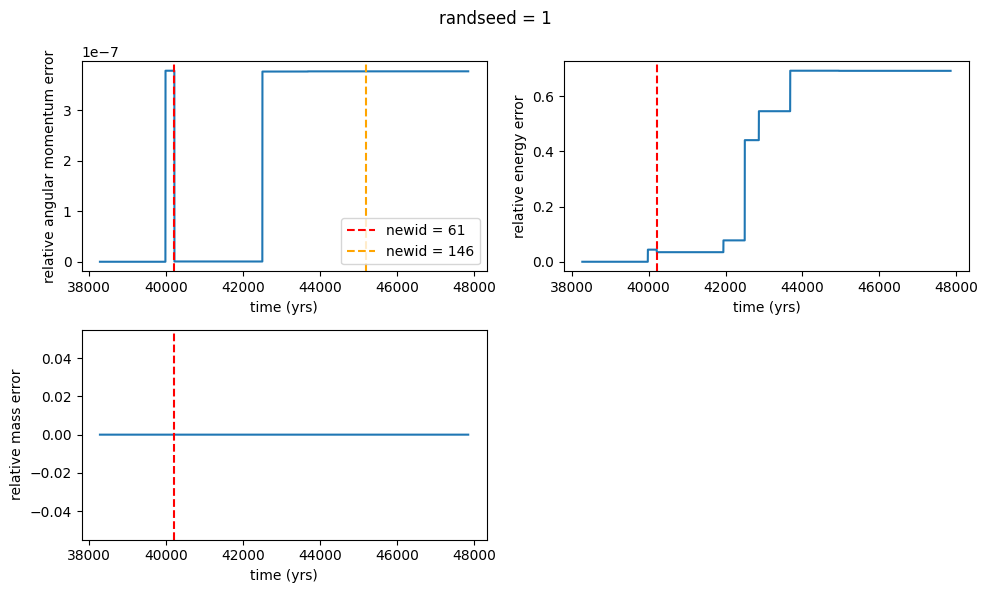

In [11]:
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.plot(heartbeat_bigstep_2['t'], heartbeat_bigstep_2['angular_momentum_error'])
plt.axvline(coll_newid_61['t'].iloc[0], color = 'red', linestyle = '--', label = 'newid = 61')
plt.axvline(coll_newid_146['t'].iloc[0], color = 'orange', linestyle = '--', label = 'newid = 146')
plt.legend()
plt.xlabel("time (yrs)")
plt.ylabel("relative angular momentum error")

plt.subplot(2,2,2)
plt.plot(heartbeat_bigstep_2['t'], heartbeat_bigstep_2['energy_error'])
plt.axvline(coll_newid_61['t'].iloc[0], color = 'red', linestyle = '--')
plt.xlabel("time (yrs)")
plt.ylabel("relative energy error")

plt.subplot(2,2,3)
plt.plot(heartbeat_bigstep_2['t'], heartbeat_bigstep_2['mass_error'])
plt.axvline(coll_newid_61['t'].iloc[0], color = 'red', linestyle = '--')
plt.xlabel("time (yrs)")
plt.ylabel("relative mass error")

plt.suptitle("randseed = 1")
plt.tight_layout()